In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:

df = pd.read_csv("omnichannel_retail_sales_inventory_dataset.csv")


In [38]:
df.head

<bound method NDFrame.head of     Order_ID  Order_Date      Channel Store_Location Product_ID  Product_Name  \
0    ORD0001  2025-07-06       Online           Pune      P1003    Headphones   
1    ORD0002  2025-12-31       Online           Pune      P1001        Laptop   
2    ORD0003  2025-07-13       Online      Bangalore      P1009         Watch   
3    ORD0004  2025-11-15       Online      Hyderabad      P1004  Office Chair   
4    ORD0005  2025-06-29       Online      Hyderabad      P1008      Sneakers   
..       ...         ...          ...            ...        ...           ...   
995  ORD0996  2025-01-06        Store           Pune      P1010      Backpack   
996  ORD0997  2025-12-05   Mobile App      Hyderabad      P1005          Desk   
997  ORD0998  2025-05-25  Marketplace           Pune      P1005          Desk   
998  ORD0999  2025-10-13       Online      Hyderabad      P1009         Watch   
999  ORD1000  2025-02-26       Online         Mumbai      P1001        Laptop   

        Category  Unit_Price  Quantity_Sold  Sales_Amount  Inventory_Level  \
0    Electronics        3000              5         15000               48   
1    Electronics       60000              2        120000              136   
2    Accessories        5000              2         10000              105   
3      Furniture        7000              2         14000              217   
4       Footwear        3500              3         10500               70   
..           ...         ...            ...           ...              ...   
995  Accessories        1500              5          7500              407   
996    Furniture       12000              1         12000              134   
997    Furniture       12000              3         36000              393   
998  Accessories        5000              2         10000              179   
999  Electronics       60000              2        120000              265   

     Reorder_Level Customer_Segment Payment_Method Region  
0               27      Home Office           Cash   East  
1               41         Consumer            UPI   West  
2               40      Home Office           Cash  South  
3               44        Corporate     Debit Card   West  
4               13         Consumer     Debit Card   West  
..             ...              ...            ...    ...  
995             28        Corporate           Cash   East  
996             36      Home Office            UPI  North  
997             33      Home Office     Debit Card  South  
998             34        Corporate           Cash   West  
999             46      Home Office     Debit Card  South  

[1000 rows x 15 columns]>

In [39]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Order_ID          1000 non-null   object
 1   Order_Date        1000 non-null   object
 2   Channel           1000 non-null   object
 3   Store_Location    1000 non-null   object
 4   Product_ID        1000 non-null   object
 5   Product_Name      1000 non-null   object
 6   Category          1000 non-null   object
 7   Unit_Price        1000 non-null   int64 
 8   Quantity_Sold     1000 non-null   int64 
 9   Sales_Amount      1000 non-null   int64 
 10  Inventory_Level   1000 non-null   int64 
 11  Reorder_Level     1000 non-null   int64 
 12  Customer_Segment  1000 non-null   object
 13  Payment_Method    1000 non-null   object
 14  Region            1000 non-null   object
dtypes: int64(5), object(10)
memory usage: 117.3+ KB


In [40]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [41]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Channel,0
Store_Location,0
Product_ID,0
Product_Name,0
Category,0
Unit_Price,0
Quantity_Sold,0
Sales_Amount,0


In [42]:
df = df.drop_duplicates()

In [43]:
df['Stock_Status'] = df['Inventory_Level'] < df['Reorder_Level']

In [44]:
df['Channel'].value_counts()

,count
Channel,
Store,255
Mobile App,251
Marketplace,250
Online,244


In [45]:
df['Customer_Segment'].value_counts()

,count
Customer_Segment,
Corporate,354
Home Office,327
Consumer,319


In [46]:
df['Region'].value_counts()

,count
Region,
East,266
North,251
West,249
South,234


<function matplotlib.pyplot.show(close=None, block=None)>

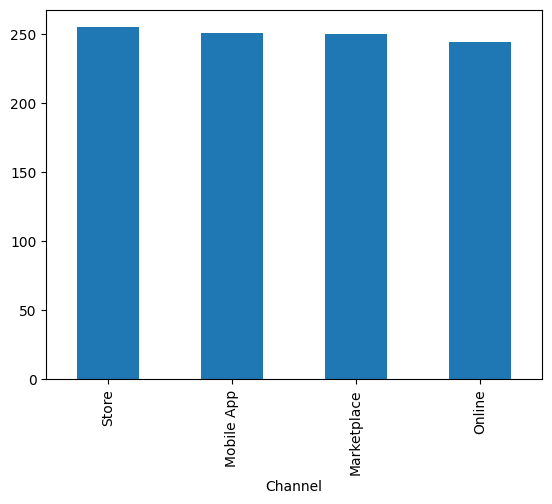

In [47]:
df['Channel'].value_counts().plot(kind='bar')
plt.show

In [48]:
df[['Quantity_Sold','Sales_Amount']].corr()

,Quantity_Sold,Sales_Amount
Quantity_Sold,1.000000,0.254991
Sales_Amount,0.254991,1.000000


In [49]:
df.groupby('Category') ['Sales_Amount'].sum().sort_values(ascending=False)

,Sales_Amount
Category,
Electronics,28362000
Furniture,5874000
Accessories,1804000
Footwear,1036000
Clothing,872000


In [50]:
df.groupby('Channel')['Sales_Amount'].sum()

,Sales_Amount
Channel,
Marketplace,8515600
Mobile App,9555800
Online,9740100
Store,10136500


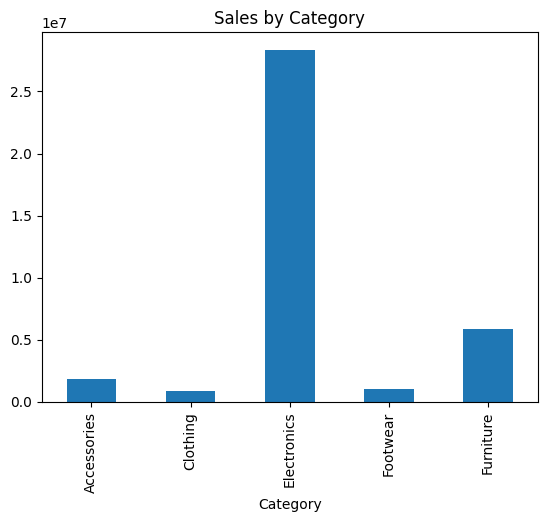

In [51]:
df.groupby('Category')['Sales_Amount'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.show()

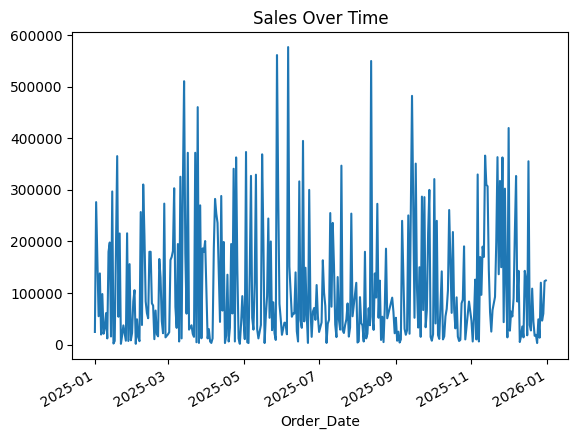

In [52]:
sales_trend = df.groupby('Order_Date')['Sales_Amount'].sum()

sales_trend.plot()
plt.title("Sales Over Time")
plt.show()

In [53]:
df['Stock_Status'].value_counts()

,count
Stock_Status,
False,981
True,19


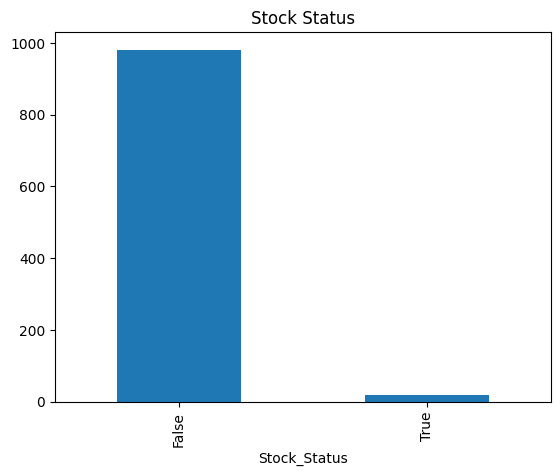

In [54]:
df['Stock_Status'].value_counts().plot(kind='bar')
plt.title("Stock Status")
plt.show()

In [55]:
df.groupby('Region')['Sales_Amount'].sum()

,Sales_Amount
Region,
East,10751400
North,10138300
South,8707300
West,8351000


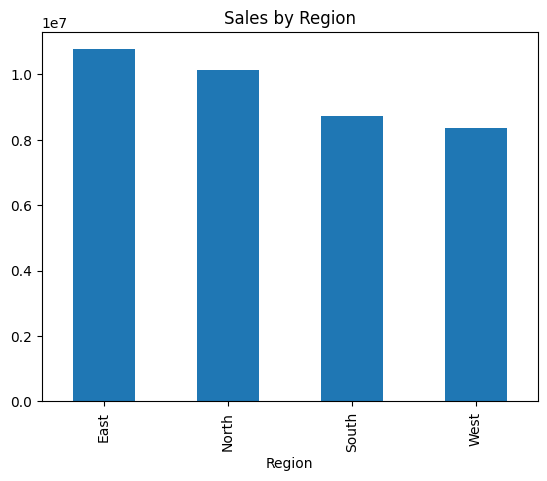

In [56]:
df.groupby('Region')['Sales_Amount'].sum().plot(kind='bar')
plt.title("Sales by Region")
plt.show()

In [57]:
df['Payment_Method'].value_counts()

,count
Payment_Method,
Debit Card,216
Credit Card,213
Net Banking,194
UPI,189
Cash,188


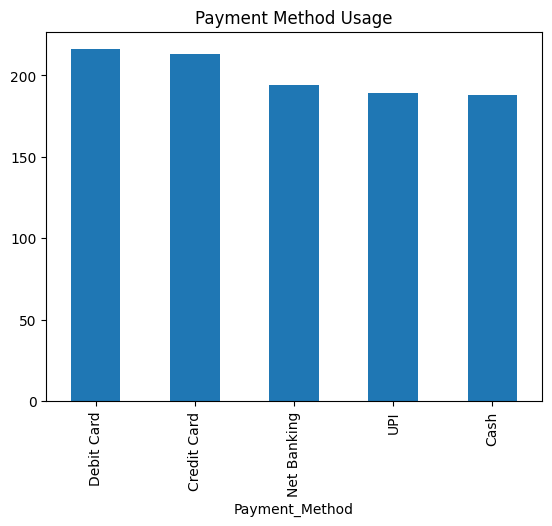

In [58]:
df['Payment_Method'].value_counts().plot(kind='bar')
plt.title("Payment Method Usage")
plt.show()

In [59]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix
correlation = numeric_df.corr()

# Show it
correlation

,Unit_Price,Quantity_Sold,Sales_Amount,Inventory_Level,Reorder_Level
Unit_Price,1.000000,-0.031883,0.866071,-0.010213,0.000639
Quantity_Sold,-0.031883,1.000000,0.254991,-0.012703,-0.007445
Sales_Amount,0.866071,0.254991,1.000000,-0.015719,0.014742
Inventory_Level,-0.010213,-0.012703,-0.015719,1.000000,-0.007730
Reorder_Level,0.000639,-0.007445,0.014742,-0.007730,1.000000


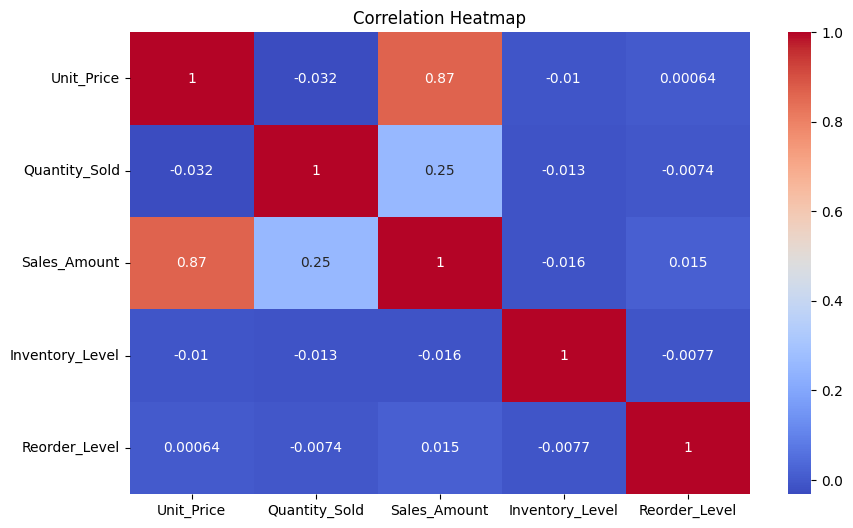

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

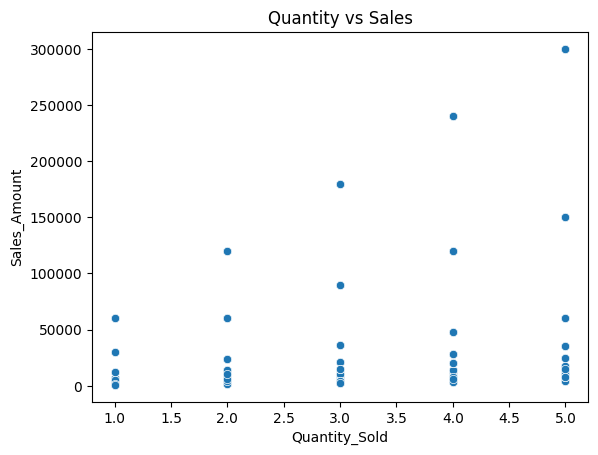

In [61]:
sns.scatterplot(x='Quantity_Sold', y='Sales_Amount', data=df)
plt.title("Quantity vs Sales")
plt.show()

1)Sales performance is mainly driven by Quantity Sold and Unit Price, showing a strong relationship with Sales Amount.
2)Corporate customer segment contributes the highest revenue, making it the most valuable segment.
3)The East region shows the strongest sales performance compared to other regions.
4)Among channels, the Store channel slightly outperforms others in generating sales.
5)Debit Card is the most preferred payment method among customers.
6)Certain product categories generate higher sales, indicating better demand.
7)Time-based analysis shows variation in sales over different periods, helping identify peak and low demand times.
8) Inventory analysis highlights that some products are below reorder level, indicating the need for restocking.
9)Correlation analysis confirms that Sales Amount increases with both price and quantity, supported by heatmap visualization.